<a href="https://colab.research.google.com/github/MeothexEtudiant2022/PROTOTYPE_JOSEPHINECARE/blob/main/ELE767_Lab2_Perceptron_Patrick_Mika_Tarek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
"""
====================================================================
PROJECT INFORMATION
====================================================================

Project Name   : Classification de signaux de parole avec réseaux de neurones
Course         : ELE767 – Intelligence Artificielle / Machine Learning
Institution    : École de Technologie Supérieure (ÉTS)

Software Name  : Lab2_Perceptron
Version        : 1.0
Language       : Python

Author         : Patrick Kijowski, Tarek Xavier Chirara, Mika Beaudet-Casimir
Date           : 2026

--------------------------------------------------------------------

DESCRIPTION

Implémentation complète de la section 3.9 du laboratoire :
conception, entraînement, visualisation et sauvegarde d’un
perceptron pour la classification multiclasse de signaux acoustiques.

Le programme inclut :
- Chargement de la base de données data.csv
- Vérification de la structure des données
- Création des ensembles d'entraînement et de test avec K-Fold
- Conception du perceptron
- Entraînement du modèle
- Affichage des courbes de précision et de perte
- Sauvegarde du modèle entraîné dans le dossier "modeles"

--------------------------------------------------------------------
"""

import os
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

In [7]:
# =========================================================
# LECTURE ET VALIDATION DE LA BASE DE DONNEES
# =========================================================

data_ds = pd.read_csv("data.csv")

print("==================================================")
print("INFORMATIONS GENERALES SUR data.csv")
print("==================================================")
print(data_ds.info())
print()

print("==================================================")
print("5 PREMIERES LIGNES")
print("==================================================")
print(data_ds.head())
print()

print("==================================================")
print("5 DERNIERES LIGNES")
print("==================================================")
print(data_ds.tail())
print()

# Vérifications minimales
if "number" not in data_ds.columns:
    raise ValueError("ERREUR : la colonne 'number' est absente de data.csv.")

print("==================================================")
print("VERIFICATION DES CLASSES")
print("==================================================")
print("Classes presentes :", sorted(data_ds["number"].unique()))
print("Nombre de classes :", data_ds["number"].nunique())
print()

print("==================================================")
print("DIMENSIONS DU DATASET")
print("==================================================")
print("Nombre de lignes   :", data_ds.shape[0])
print("Nombre de colonnes :", data_ds.shape[1])
print()

if data_ds.shape[1] != 1561:
    print("ATTENTION : le dataset ne contient pas exactement 1561 colonnes.")
    print("Le labo suggere normalement 1560 caracteristiques + 1 colonne 'number'.")

INFORMATIONS GENERALES SUR data.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 890 entries, 0 to 889
Columns: 1561 entries, W0_MS_0 to number
dtypes: float64(1560), int64(1)
memory usage: 10.6 MB
None

5 PREMIERES LIGNES
    W0_MS_0   W0_MS_1   W0_MS_2   W0_MS_3   W0_MS_4   W0_MS_5   W0_MS_6  \
0  1.011981  2.142074  0.588728 -0.692308 -0.203841  1.042901 -0.537213   
1  0.083026  2.450909  0.818768  3.092884 -0.610867  4.112420  0.218586   
2  0.127918  1.936767  0.395461  1.011786 -0.208603  0.058295 -0.453895   
3  0.673839  1.831173  2.084694  0.548835 -0.690189  0.056046  0.763344   
4  2.182024 -0.060605 -0.000992  1.056996 -0.412494 -0.210797  1.100925   

    W0_MS_7   W0_MS_8   W0_MS_9  ...  W59_MD_4  W59_MD_5  W59_MD_6  W59_MD_7  \
0  0.498876 -0.680100 -0.737847  ...  0.581696 -0.422061 -0.210426 -0.492524   
1  0.147865  0.820458  1.024225  ... -0.554939 -0.722586 -0.363003 -0.661282   
2  1.157127 -0.097942  1.268917  ... -0.578180 -0.587715 -0.715070 -0.785123   
3

In [8]:
# =========================================================
# FONCTION : CREATION DES ENSEMBLES TRAIN / TEST
# =========================================================

def create_sets(data_ds, n_fold=5, batch_size=1, shuffle_seed=42):
    """
    CREATE_SETS
    Transforme la base de donnees pour l'entrainement du modele.

    Arguments :
        data_ds      {pd.DataFrame} : base de donnees complete
        n_fold       {int}          : nombre de folds pour KFold
        batch_size   {int}          : taille des batches
        shuffle_seed {int}          : seed pour melange reproductible

    Retour :
        train_set {tf.data.Dataset}
        test_set  {tf.data.Dataset}
    """

    # Melange reproductible
    data = data_ds.sample(frac=1, random_state=shuffle_seed).reset_index(drop=True)

    # Separation des sorties
    data_output = data.pop("number")

    # KFold avec melange
    splitter = KFold(n_splits=n_fold, shuffle=True, random_state=shuffle_seed)

    # On prend seulement la premiere separation,
    # exactement dans l'esprit du support du laboratoire
    for train_index, test_index in splitter.split(data):
        X_train = data.values[train_index]
        y_train = data_output.values[train_index]

        X_test = data.values[test_index]
        y_test = data_output.values[test_index]
        break

    # Conversion en types compatibles
    X_train = X_train.astype(np.float64)
    X_test = X_test.astype(np.float64)
    y_train = y_train.astype(np.int64)
    y_test = y_test.astype(np.int64)

    # Conversion en datasets TensorFlow
    train_set = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    train_set = train_set.shuffle(len(X_train), seed=shuffle_seed).batch(batch_size)

    test_set = tf.data.Dataset.from_tensor_slices((X_test, y_test))
    test_set = test_set.shuffle(len(X_test), seed=shuffle_seed).batch(batch_size)

    return train_set, test_set

In [9]:
# =========================================================
# FONCTION : ENTRAINEMENT DU MODELE
# =========================================================

def training(model, data_ds, epochs=25, n_fold=5, batch_size=1,
             verbose_train=1, verbose_test=0, shuffle_seed=42):
    """
    TRAINING
    Entraine un modele et retourne ses statistiques.

    Arguments :
        model         {tf.keras.Model} : modele a entrainer
        data_ds       {pd.DataFrame}   : base de donnees complete
        epochs        {int}            : nombre d'epoques
        n_fold        {int}            : nombre de folds
        batch_size    {int}            : taille des batches
        verbose_train {int}            : affichage de l'entrainement
        verbose_test  {int}            : affichage de l'evaluation
        shuffle_seed  {int}            : seed de reproductibilite

    Retour :
        {dict} :
            train_accuracy
            train_loss
            test_accuracy
            test_loss
    """

    train_accuracy = []
    train_loss = []
    test_accuracy = []
    test_loss = []

    train_set, test_set = create_sets(
        data_ds=data_ds,
        n_fold=n_fold,
        batch_size=batch_size,
        shuffle_seed=shuffle_seed
    )

    # Evaluation avant apprentissage
    result = model.evaluate(train_set, verbose=verbose_train)
    train_loss.append(result[0])
    train_accuracy.append(result[1])

    result = model.evaluate(test_set, verbose=verbose_test)
    test_loss.append(result[0])
    test_accuracy.append(result[1])

    # Boucle d'entrainement
    for e in range(epochs):
        print(f"Epoch #{e + 1}")

        fit_result = model.fit(train_set, epochs=1, verbose=verbose_train)
        train_loss.append(fit_result.history["loss"][-1])
        train_accuracy.append(fit_result.history["accuracy"][-1])

        eval_result = model.evaluate(test_set, verbose=verbose_test)
        test_loss.append(eval_result[0])
        test_accuracy.append(eval_result[1])

    return {
        "train_accuracy": train_accuracy,
        "train_loss": train_loss,
        "test_accuracy": test_accuracy,
        "test_loss": test_loss
    }

In [10]:
# =========================================================
# FONCTION : AFFICHAGE DES STATISTIQUES
# =========================================================

def figure(training_dict, suptitle, figsize=(12, 6)):
    """
    FIGURE
    Produit les courbes de precision et de perte.
    """

    plt.figure(figsize=figsize, facecolor='w')
    plt.suptitle(suptitle)

    # Sous-figure 1 : precision
    plt.subplot(121)
    plt.title("Precision du modele")
    plt.xlabel("Nombre d'epoques")
    plt.ylabel("Precision de la classification")
    plt.plot(training_dict["train_accuracy"], 'r', label='training')
    plt.plot(training_dict["test_accuracy"], 'y', label='test')
    plt.ylim(0, 1.01)
    plt.grid()
    plt.minorticks_on()
    plt.legend()

    # Sous-figure 2 : perte
    plt.subplot(122)
    plt.title("Perte du modele")
    plt.xlabel("Nombre d'epoques")
    plt.ylabel("Resultat de la fonction de perte")
    plt.plot(training_dict["train_loss"], 'r', label='training')
    plt.plot(training_dict["test_loss"], 'y', label='test')
    plt.ylim(0)
    plt.grid()
    plt.minorticks_on()
    plt.legend()

    plt.show()

In [11]:
# =========================================================
# CONCEPTION DU PERCEPTRON
# =========================================================

perceptron = tf.keras.Sequential([
    layers.Dense(4, activation='sigmoid', dtype='float64')
])

perceptron.compile(
    optimizer='SGD',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("==================================================")
print("MODELE PERCEPTRON CREE ET COMPILE AVEC SUCCES")
print("==================================================")
perceptron.summary()

MODELE PERCEPTRON CREE ET COMPILE AVEC SUCCES


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# =========================================================
# ENTRAINEMENT DU PERCEPTRON
# =========================================================

result = training(
    model=perceptron,
    data_ds=data_ds,
    epochs=25,
    n_fold=5,
    batch_size=1,
    verbose_train=1,
    verbose_test=0,
    shuffle_seed=42
)

712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2093 - loss: 1.5514
Epoch #1
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6826 - loss: 0.7659
Epoch #2
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9354 - loss: 0.1848
Epoch #3
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9691 - loss: 0.0746
Epoch #4
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9916 - loss: 0.0195
Epoch #5
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9958 - loss: 0.0074
Epoch #6
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9986 - loss: 0.0047
Epoch #7
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9986 - loss: 0.0038
Epoch #8
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9986 - loss: 0.0032
Epoch #9
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9986 - loss: 0.0026
Epoch #10
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9986 - loss: 0.0022
Epoch #11
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9986 - loss: 0.0020

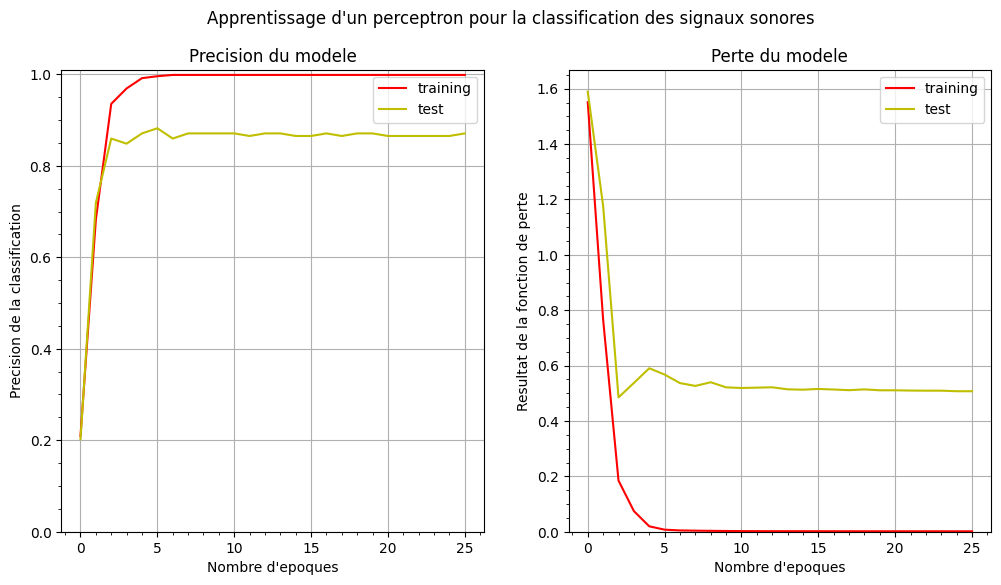

In [13]:
# =========================================================
# AFFICHAGE DES RESULTATS
# =========================================================

figure(
    result,
    "Apprentissage d'un perceptron pour la classification des signaux sonores"
)

In [16]:
# =========================================================
# SAUVEGARDE DU MODELE
# =========================================================

os.makedirs("modeles", exist_ok=True)
perceptron.save("modeles/perceptron.keras")

print("==================================================")
print("MODELE SAUVEGARDE DANS : modeles/perceptron.keras")
print("==================================================")

MODELE SAUVEGARDE DANS : modeles/perceptron.keras


In [17]:
# =========================================================
# VERIFICATION DES FICHIERS CREES
# =========================================================

!ls -lah
print()
!ls -lah modeles

total 25M
drwxr-xr-x 1 root root 4.0K Apr  2 20:51 .
drwxr-xr-x 1 root root 4.0K Apr  2 17:35 ..
drwxr-xr-x 4 root root 4.0K Mar 30 13:29 .config
-rw-r--r-- 1 root root  25M Apr  2 20:49 data.csv
drwxr-xr-x 2 root root 4.0K Apr  2 20:53 modeles
-rw-r--r-- 1 root root 155K Apr  2 20:49 mystere.csv
drwxr-xr-x 1 root root 4.0K Mar 30 13:29 sample_data

total 72K
drwxr-xr-x 2 root root 4.0K Apr  2 20:53 .
drwxr-xr-x 1 root root 4.0K Apr  2 20:51 ..
-rw-r--r-- 1 root root  64K Apr  2 20:53 perceptron.keras
